# LFP model


doing some visualization while testing how best to train the LFP bandpower-matched models

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

## get list of trained models and filter bad ones

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_list = os.listdir(model_dir)
model_list = [m for m in model_list if m.endswith('.mat')]
model_list.sort()
print(model_list)
print(len(model_list))

['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_003716.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004322.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004840.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_005023.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_010332.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011004.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011255.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_012729.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013220.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013347.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013838.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_014523.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_020447.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_020730.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_021657.mat', 'Task_xor

In [6]:
# go through models and check performance and training trials

perfs = []
train_trials = []
for i, model_name in enumerate(model_list):
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_003716.mat, Test perf: 0.99, Train trials: 6701
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004322.mat, Test perf: 0.98, Train trials: 9101
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004840.mat, Test perf: 0.99, Train trials: 11701
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_005023.mat, Test perf: 0.96, Train trials: 13001
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_010332.mat, Test perf: 0.0, Train trials: 19999
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011004.mat, Test perf: 0.98, Train trials: 8601
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011255.mat, Test perf: 0.97, Train trials: 16201
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_012729.mat, Test perf: 0.0, Train trials: 19999
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013220.mat, Test perf: 0.97, Train trials: 19601
Model: Task_xor_N_200_Taus_4.0_25

In [7]:
# get list of models with <95% accuracy
low_perf_indices = np.where(np.array(perfs) < 0.95)[0]
print(f'Number of low performance models: {len(low_perf_indices)}')


Number of low performance models: 12


In [8]:
# delete mat files with less than 95% accuracy

import os

for i in low_perf_indices:
    model_name = model_list[i]
    model_path = os.path.join(model_dir, model_name)
    os.remove(model_path)
    print(f'Deleted model: {model_name}, with performance: {perfs[i]}')


Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_010332.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_012729.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_014523.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_020447.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_020730.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_021657.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_093647.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_093852.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_093859.mat, with performance: 0.0
Deleted model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_104845.mat, with perform

In [ ]:
# remove .mat files with less than 95% accuracy

high_perf_indices = [i for i, p in enumerate(perfs) if p >= 0.95]
print(f'Number of high performance models: {len(high_perf_indices)}')

model_list = [model_list[i] for i in high_perf_indices]
perfs = [perfs[i] for i in high_perf_indices]
train_trials = [train_trials[i] for i in high_perf_indices]

## get list of trained models

In [9]:
model_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_list = os.listdir(model_dir)
model_list = [m for m in model_list if m.endswith('.mat')]
model_list.sort()
print(model_list)
print(len(model_list))

['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_003716.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004322.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004840.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_005023.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011004.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011255.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013220.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013347.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013838.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_095439.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_100635.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_101851.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_103905.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_105632.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_110756.mat', 'Task_xor

In [10]:
# go through models and check performance and training trials

perfs = []
train_trials = []
for i, model_name in enumerate(model_list):
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_003716.mat, Test perf: 0.99, Train trials: 6701
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004322.mat, Test perf: 0.98, Train trials: 9101
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004840.mat, Test perf: 0.99, Train trials: 11701
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_005023.mat, Test perf: 0.96, Train trials: 13001
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011004.mat, Test perf: 0.98, Train trials: 8601
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011255.mat, Test perf: 0.97, Train trials: 16201
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013220.mat, Test perf: 0.97, Train trials: 19601
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013347.mat, Test perf: 0.96, Train trials: 10401
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013838.mat, Test perf: 1.0, Train trials: 11901
Model: Task_xor_N_200_Taus_4.0_2

## study models

### model eval

In [11]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model
from model import generate_input_stim_xor

2025-08-28 14:56:00.234241: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-28 14:56:00.254583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-28 14:56:00.279256: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-28 14:56:00.286143: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-28 14:56:00.310715: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


In [19]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

(200, 500)
(200, 500)
(500,)
(500,)


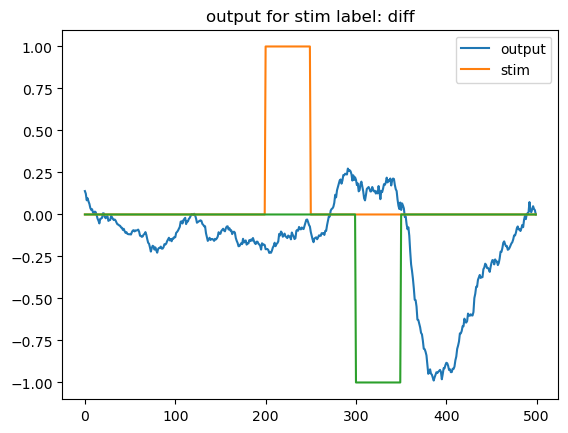

In [13]:
import importlib
importlib.reload(model)

u, label = generate_input_stim_xor(settings)
x, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_list[0]}', settings=settings, u=u)
print(x.shape)
print(r.shape)
print(o.shape)
print(epsp.shape)

plt.figure()
plt.plot(o)
plt.plot(u[0,:])
plt.plot(u[1,:])
plt.title(f'output for stim label: {label}')
plt.legend(['output','stim'])
plt.show()

In [14]:
# model eval on 100 random trials

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
eval_perf = np.zeros(n_trials)
eval_os = np.zeros((n_trials, settings['T']))

for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_xor(settings)
    _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_list[0]}', settings=settings, u=eval_u)
    eval_os[i, :] = np.squeeze(eval_o)
    if eval_label == 'same':
        if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
            eval_perf[i] = 1
    else:
        if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
            eval_perf[i] = 1

eval_perf_mean = np.nanmean(eval_perf)
print("Performance: %.2f"%(eval_perf_mean))

Performance: 0.97


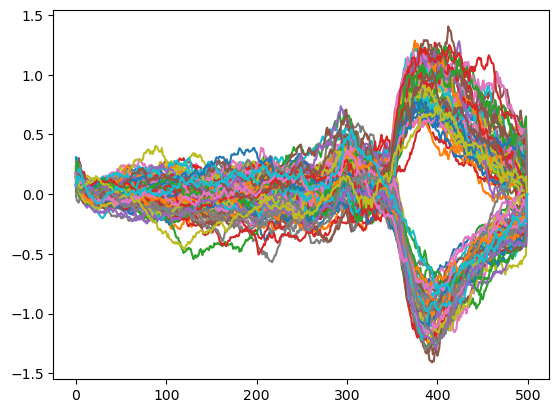

In [15]:
plt.figure()
plt.plot(eval_os.T)
plt.show()

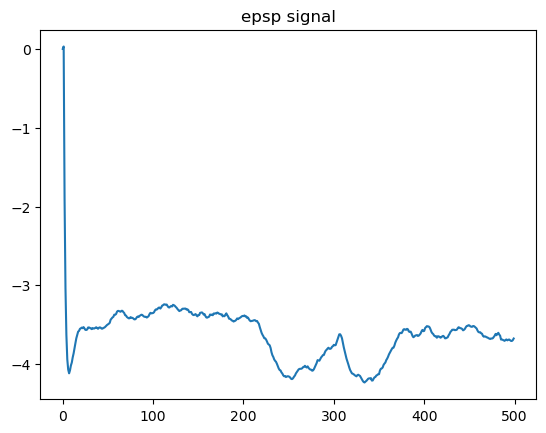

In [16]:
# check out the epsp signal

plt.figure()
plt.plot(epsp.T)
plt.title('epsp signal')
plt.show()

In [22]:
# spect calculation code in numpy

def compute_lfp_power_np(epsp, settings):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = settings['lfp_power_target']
    stim_on = settings['stim_on']

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]

    # --- baseline z-scoring ---
    start = 10
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


(500, 40)
(40,)
(500,)


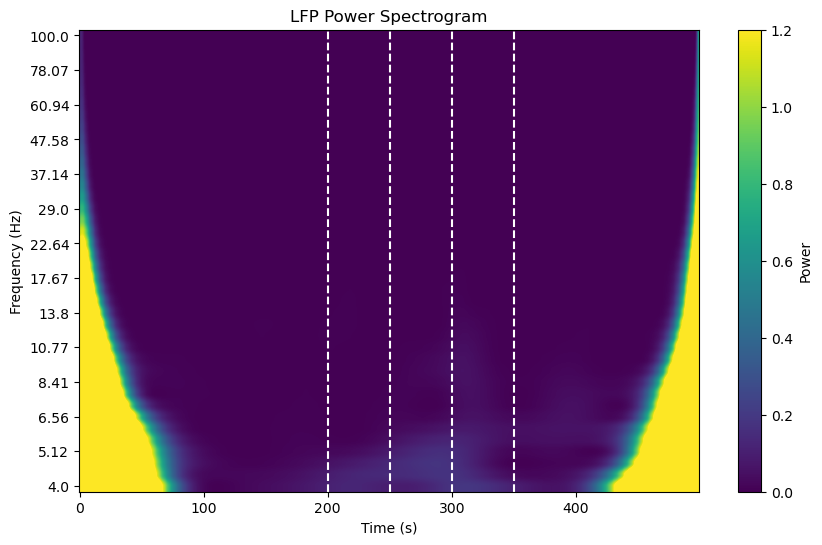

In [24]:
# plot spect

power, freqs, lfp_power_z = compute_lfp_power_np(epsp, settings)
print(power.shape)
print(freqs.shape)
print(lfp_power_z.shape)

time_cutoff = 25

plt.figure(figsize=(10, 6))
# plt.imshow(power[time_cutoff:,:].T, aspect='auto', extent=[time_cutoff, T, fmin, fmax], origin='lower',
#            vmin=0, vmax=1.2)
plt.imshow(power.T, aspect='auto', origin='lower',
           vmin=0, vmax=1.2)
# plt.axhline(y=band_lo, color='r', linestyle='--', label='Band low')
# plt.axhline(y=band_hi, color='r', linestyle='--', label='Band high')
plt.yticks()
plt.yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
plt.axvline(x=settings['stim_on'], color='w', linestyle='--', label='Stim on')
plt.axvline(x=settings['stim_on'] + settings['stim_dur'], color='w', linestyle='--', label='Stim off')
plt.axvline(x=settings['stim_on'] + settings['stim_dur'] + settings['delay'], color='w', linestyle='--', label='2nd Stim on')
plt.axvline(x=settings['stim_on'] + 2*settings['stim_dur'] + settings['delay'], color='w', linestyle='--', label='2nd Stim off')
plt.colorbar(label='Power')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('LFP Power Spectrogram')
plt.show()

### Trajectory plots

In [25]:

from sklearn.decomposition import PCA


In [31]:
model_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x0', 'r0', 'w0', 'taus_gaus0', 'w_in0', 'u', 'o', 'w', 'x', 'target', 'w_out', 'r', 'm', 'som_m', 'N', 'exc', 'inh', 'w_in', 'b_out', 'som_N', 'losses', 'taus', 'eval_perf_mean', 'eval_loss_mean', 'eval_os', 'eval_labels', 'taus_gaus', 'tr', 'activation'])

In [37]:
r = model_data['r']
r = np.squeeze(r)
r.shape

exc = model_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = model_data['inh']
inh_ind = np.where(inh == 1)[0]

X (r): time x neurons  

U: time x n_components  

S: n_components  

Vt: n_components x neurons  

In [28]:
# X = USVt

pca = PCA(n_components=100).fit(r)
r_U = pca.transform(r)
r_S = pca.singular_values_
r_Vt = pca.components_

print(r_U.shape)
print(r_S.shape)
print(r_Vt.shape)

(500, 100)
(100,)
(100, 200)


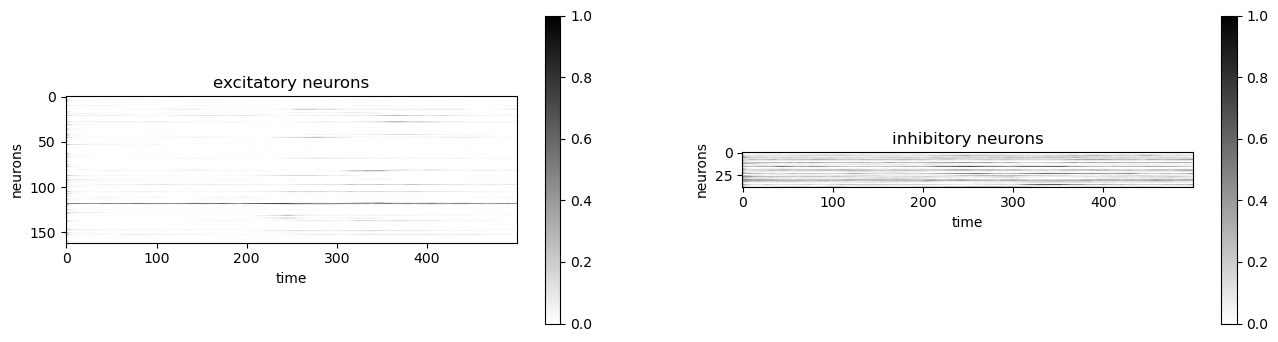

162 excitatory neurons
38 inhibitory neurons


In [38]:
fig,axs = plt.subplots(1,2,figsize=(16,4))
im1 = axs[0].imshow(r[:,exc_ind].T,cmap='binary',vmin=0, vmax=1)
axs[0].set_xlabel('time')
axs[0].set_ylabel('neurons')
axs[0].set_title('excitatory neurons')
fig.colorbar(im1)

im2 = axs[1].imshow(r[:,inh_ind].T,cmap='binary',vmin=0, vmax=1)
axs[1].set_xlabel('time')
axs[1].set_ylabel('neurons')
axs[1].set_title('inhibitory neurons')
fig.colorbar(im2)

plt.show()

print(f'{len(exc_ind)} excitatory neurons')
print(f'{len(inh_ind)} inhibitory neurons')

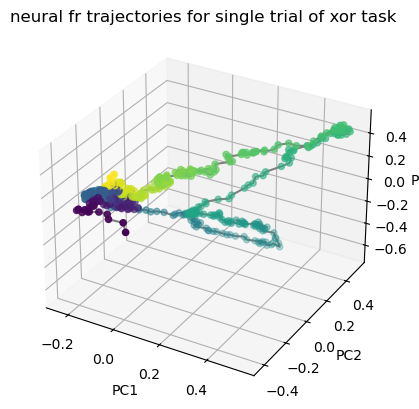

In [41]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(r_U[5:,0], r_U[5:,1], r_U[5:,2], c=range(r_U.shape[0]-5))
ax.plot3D(r_U[5:,0], r_U[5:,1], r_U[5:,2], 'gray')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('neural fr trajectories for single trial of xor task')
plt.show()

In [11]:
def generate_xor_type(T, stim_on, stim_dur, delay, stim1=1, stim2=-1):
     
     u = np.zeros((2, T))
     
     u[0, stim_on:stim_on+stim_dur] = stim1
     u[1, stim_on+stim_dur+delay:stim_on+2*stim_dur+delay] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

### some connectivity stuff

In [44]:
all_models_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'

In [49]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import connectivity_utils as cu

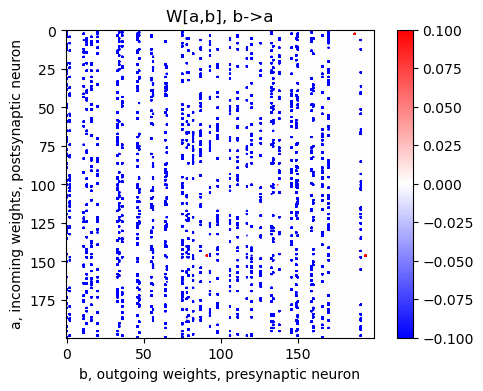

In [52]:
w = model_data['w']
m = model_data['m']
final_w = np.matmul(w, m)
cu.plot_connectivity_matrix(final_w)

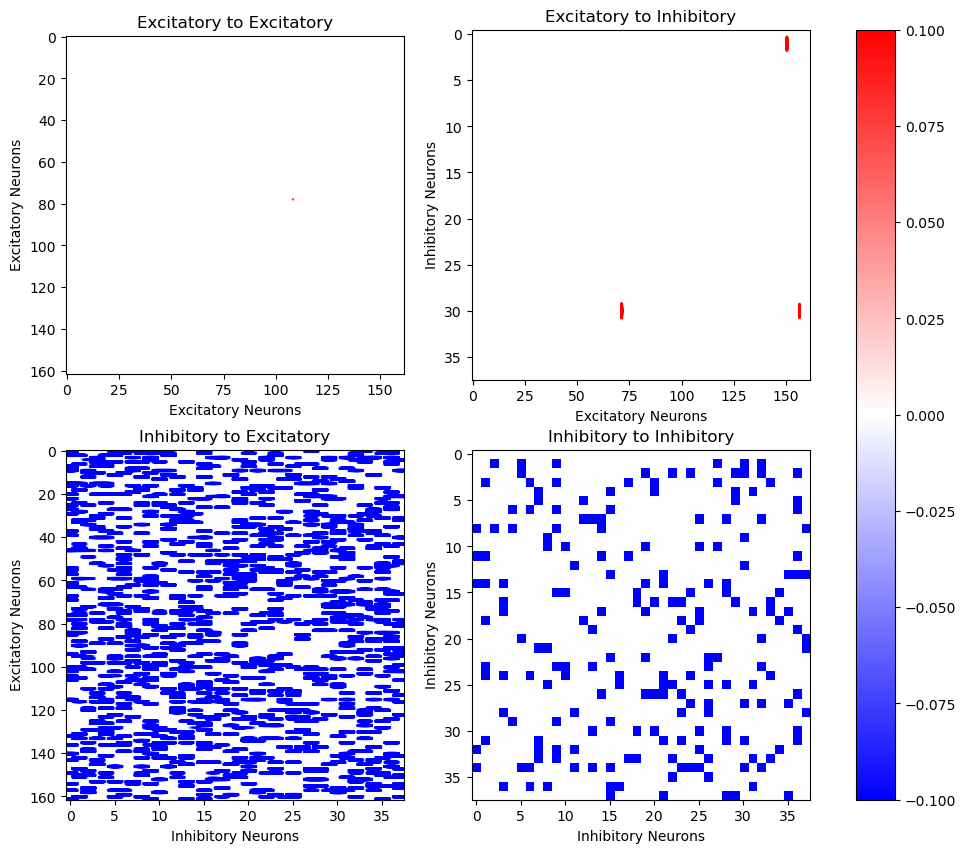

In [53]:
cu.plot_connectivity_matrix_by_type(final_w, exc_ind, inh_ind)

In [54]:
def get_num_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ii != 0), np.sum(ee != 0), np.sum(ei != 0), np.sum(ie != 0), 

def get_proportion_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ee != 0) / ee.size, np.sum(ii != 0) / ii.size, np.sum(ei != 0) / ei.size, np.sum(ie != 0) / ie.size

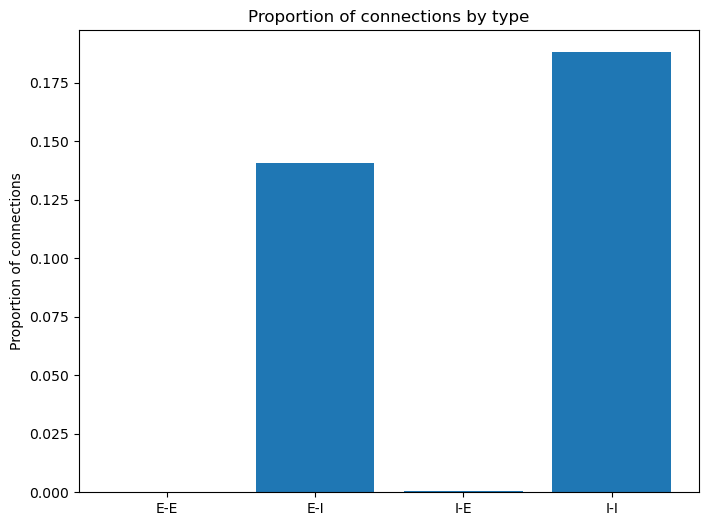

In [55]:
connect_props = get_proportion_connections(final_w, exc_ind, inh_ind)

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'E-I', 'I-E', 'I-I'], connect_props)
plt.ylabel('Proportion of connections')
plt.title('Proportion of connections by type')
plt.show()

In [ ]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import FR_RNN_dale


In [58]:
# plot comparing trained and untrained

trained_num = []
untrained_num = []
trained_prop = []
untrained_prop = []

for model_num in range(len(model_list)):
    
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    
    # trained
    w = model_data['w']
    m = model_data['m']
    W = np.matmul(w, m)
    
    exc = model_data['exc']
    exc_ind = np.where(exc == 1)[0]
    inh = model_data['inh']
    inh_ind = np.where(inh == 1)[0]
    
    
    trained_num.append(get_num_connections(W, exc_ind, inh_ind))
    trained_prop.append(get_proportion_connections(W, exc_ind, inh_ind))

    # untrained
    N = 200
    net = FR_RNN_dale(N, .2, .2, np.float32(np.random.randn(N, 2)), 0, 'gaus', 1.5, True, np.float32(np.random.randn(1, N)/100))
    W_init = net.W @ net.mask
    exc_ind_init = np.where(net.exc == 1)[0]
    inh_ind_init = np.where(net.exc == 0)[0]

    untrained_num.append(get_num_connections(W_init, exc_ind_init, inh_ind_init))
    untrained_prop.append(get_proportion_connections(W_init, exc_ind_init, inh_ind_init))
# convert to numpy arrays
trained_num = np.array(trained_num)
untrained_num = np.array(untrained_num)
trained_prop = np.array(trained_prop)
untrained_prop = np.array(untrained_prop)

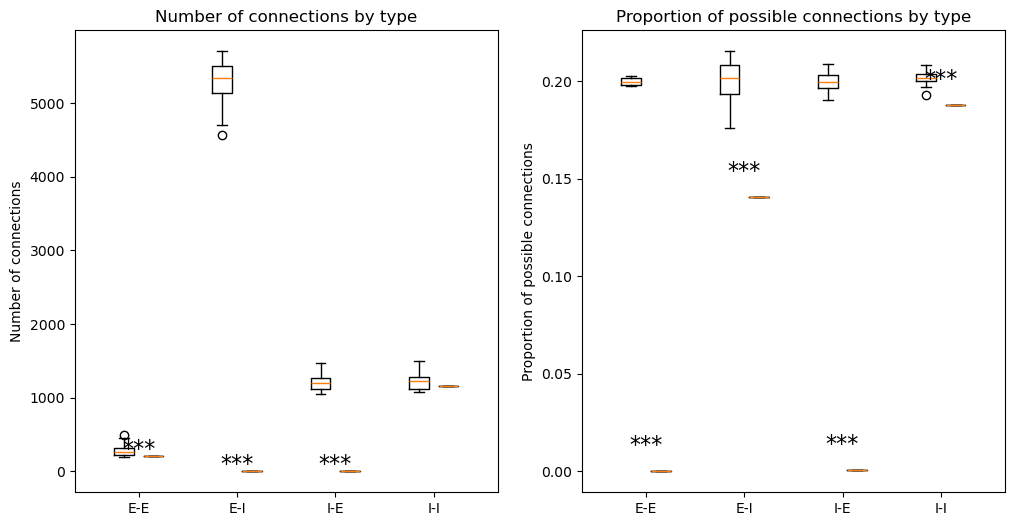

In [59]:
# plot trained vs untrained number of connections

connection_types = ['E-E', 'E-I', 'I-E', 'I-I']
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].boxplot(untrained_num, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[0].boxplot(trained_num, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[0].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[0].set_ylabel('Number of connections')
axs[0].set_title('Number of connections by type')
# axs[0].legend()

axs[1].boxplot(untrained_prop, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[1].boxplot(trained_prop, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[1].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[1].set_ylabel('Proportion of possible connections')
axs[1].set_title('Proportion of possible connections by type')
# axs[1].legend() 

# plot mann whitney U test results for num and proportion of connections
from scipy.stats import mannwhitneyu
p_values_num = []
p_values_prop = []
# for number of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_num[:, i], untrained_num[:, i])
    p_values_num.append(p)
p_values_num = np.array(p_values_num)

# for proportion of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_prop[:, i], untrained_prop[:, i])
    p_values_prop.append(p)
p_values_prop = np.array(p_values_prop)

# plot p-values as stars on top of the boxplots
for i, p in enumerate(p_values_num):
    if p < 0.001:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '*', fontsize=16, ha='center')
    
for i, p in enumerate(p_values_prop):
    if p < 0.001:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '*', fontsize=16, ha='center')

# plt.tight_layout()

plt.show()

### neural outputs from spiking model

In [14]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import single_neuron_utils as sn

In [20]:
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'

model_name = model_fname[:-4]
model_dir = os.path.join(all_models_dir, model_name)
delay=50

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
data_files

['/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/neuraldata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/timingdata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/bhvdata_raw_delay50.mat']

In [21]:
# neural data
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True,
                                                  all_models_dir = all_models_dir)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)
times_ms, _,_ = ld.get_times_dict('ds', 'delay', 50, model_name,
                                  all_models_dir=all_models_dir)

In [22]:
print(f'Average performance for delay {delay}: {trial_perfs.mean()}')

Average performance for delay 50: 0.511


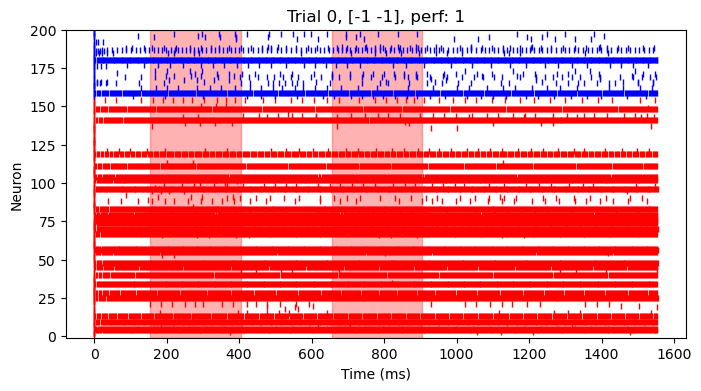

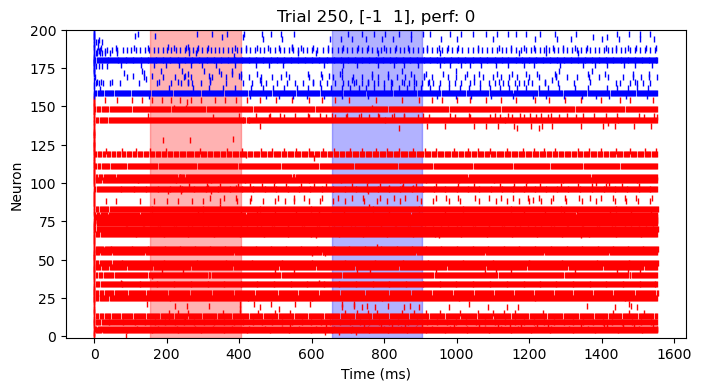

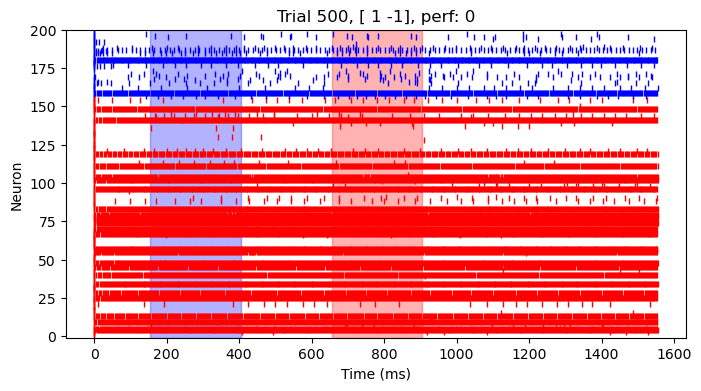

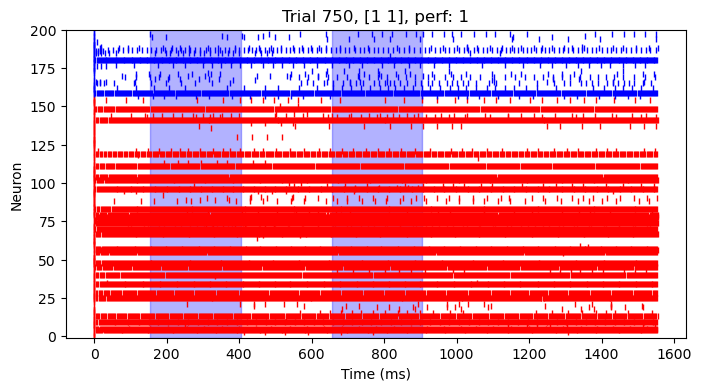

In [23]:
for trial_id in [0, 250, 500, 750]:
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]
    sn.plot_trial_raster(trial_df, 'delay', 50, all_models_dir=all_models_dir,)